#### Задача \ Описание действий:

1. Реализовать граф вычислительный на основе LangChain
2. Реализовтаь интеграцию с YandexGPTFoundation

# Import libs

In [1]:
import json
from typing import TypedDict, List, Optional
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
import asyncio

# Работаем с секретами
from dotenv import load_dotenv
import os

# Define general args

In [2]:
load_dotenv("../../.env")

True

In [3]:
openai_api_key=os.getenv("API_KEY")
FOLDER_ID = os.getenv("FOLDER_ID")
openai_api_base="https://llm.api.cloud.yandex.net/v1"
model=f"gpt://{FOLDER_ID}/yandexgpt"

# Define LLM State

In [4]:
class AgentState(TypedDict):
    text: str
    is_valid: bool
    validation_errors: List[str]
    answers: List[str]
    parts: List[str]
    final_answer: str
    

# Define LLM object

In [5]:
llm = ChatOpenAI(
    model=model,
    temperature=0,
    openai_api_base=openai_api_base,
    openai_api_key=openai_api_key, 
)

# Define functions

In [12]:
class ValidationAgent:
    def __init__(self, llm, prompt_dir="../../prompts", s3_info: Optional[dict] = {}):
        self.llm = llm
        self.s3_info = s3_info
        self.prompts = {
            "validate": self.load_prompt(f"{prompt_dir}/validate_text.txt", how="local"),
            "decompose": self.load_prompt(f"{prompt_dir}/decompose_question.txt", how="local"),
            "answer_part": self.load_prompt(f"{prompt_dir}/answer_part.txt", how="local"),
            "collect_final": self.load_prompt(f"{prompt_dir}/collect_final_answer.txt", how="local"),
            "validate_final": self.load_prompt(f"{prompt_dir}/validate_final_answer.txt", how="local")
        }

    @staticmethod
    def load_prompt(path: str, how: str = "local") -> str:
        if how == "local":
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
        elif how == "s3":
            with boto3.client('s3') as s3:
                bucket = s3_params["bucket"]
                key = s3_params["key"]
                obj = s3.get_object(Bucket=bucket, Key=key)
                return obj['Body'].read().decode('utf-8')
        else:
            raise NotImplementedError(f"Unknown source: {how}")
        
    def validate_text(self, state: AgentState) -> AgentState:
        prompt = ChatPromptTemplate.from_template(self.prompts["validate"])
        chain = prompt | self.llm
        response = chain.invoke({"text": state["text"]}).content.strip().lower()
        if "да" in response:
            state["is_valid"] = True
            state["validation_errors"] = []
        else:
            state["is_valid"] = False
            state["final_answer"] = response
            msg = response.replace("нет", "").strip()
            state["validation_errors"] = [msg] if msg else ["Не прошёл валидацию"]
        return state

    def decompose_question(self, state: AgentState) -> AgentState:
        prompt = ChatPromptTemplate.from_template(self.prompts["decompose"])
        chain = prompt | self.llm
        response = chain.invoke({"text": state["text"]}).content.strip()
        state["parts"] = [line.strip("- ").strip() for line in response.split("\n") if line.strip()]
        return state

    async def answer_parts_async(self, state: AgentState, max_concurrent: int = 3) -> AgentState:
        semaphore = asyncio.Semaphore(max_concurrent)
        prompt = ChatPromptTemplate.from_template(self.prompts["answer_part"])
        chain = prompt | self.llm

        async def call_llm(part):
            async with semaphore:
                return (await chain.ainvoke({"text": part})).content.strip()

        tasks = [asyncio.create_task(call_llm(part)) for part in state["parts"]]
        results = await asyncio.gather(*tasks)
        state["answers"] = results
        return state

    def collect_final_answer(self, state: AgentState) -> AgentState:
        if state.get("answers"):
            answers_text = "\n".join(f"{i + 1}. {ans}" for i, ans in enumerate(state["answers"]))
            prompt = ChatPromptTemplate.from_template(self.prompts["collect_final"])
            chain = prompt | self.llm
            response = chain.invoke({"answers": answers_text}).content.strip()
            state["final_answer"] = response
        else:
            state["final_answer"] = "Нет данных для итогового ответа."
        return state

    def validate_final_answer(self, state: AgentState) -> AgentState:
        prompt = ChatPromptTemplate.from_template(self.prompts["validate_final"])
        chain = prompt | self.llm
        output = chain.invoke({
            "question": state["text"],
            "answer": state["final_answer"]
        }).content.strip().lower()
        state["summary_is_complete"] = "да" in output
        return state

    def reject_stub(self, state: AgentState) -> AgentState:
        state["final_answer"] = "Текст не соответсвует тематике вопросов для диалога с чат-ботом. Повторите свой вопрос еще раз."
        return state


In [13]:
# Ветка выбора: если валидация пройдена — генерация ответа; иначе — stub
def route(state: AgentState):
    return "decompose_question" if state["is_valid"] else "reject_stub"

# Init LLM class custom

In [14]:
agent = ValidationAgent(llm)

# Build Graph

In [15]:
builder = StateGraph(AgentState, is_async=True)
builder.add_node("validate", agent.validate_text)
builder.add_node("decompose_question", agent.decompose_question)
builder.add_node("answer_parts_async", agent.answer_parts_async)
builder.add_node("reject_stub", agent.reject_stub)
builder.add_node("collect_final_answer", agent.collect_final_answer)
builder.add_node("validate_final_answer", agent.validate_final_answer)

builder.set_entry_point("validate")

def route(state: AgentState):
    return "decompose_question" if state["is_valid"] else "reject_stub"

builder.add_conditional_edges("validate", route, {
    "decompose_question": "decompose_question",
    "reject_stub": "reject_stub"
})

builder.add_edge("reject_stub", END)
builder.add_edge("decompose_question", "answer_parts_async")
builder.add_edge("answer_parts_async", "collect_final_answer")
builder.add_edge("collect_final_answer", "validate_final_answer")
builder.add_edge("validate_final_answer", END)

validation_agent = builder.compile()


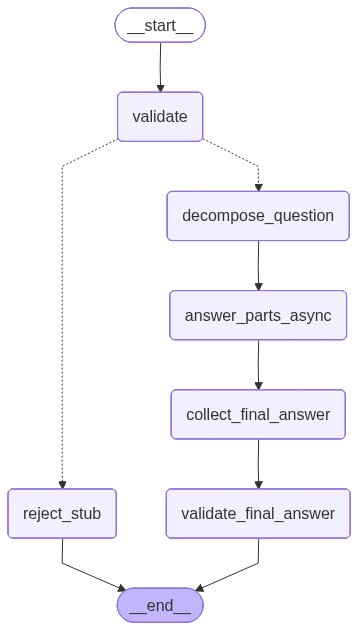

In [16]:
validation_agent

# Init test LLM

In [17]:
start_state = {
    "text": "Как защитить свои права?",
    "is_valid": False,
    "validation_errors": [],
    "parts": [],
    "answers": [],
    "final_answer": ""
}

result = await validation_agent.ainvoke(start_state)
print(result["final_answer"])

Текст не соответсвует тематике вопросов для диалога с чат-ботом. Повторите свой вопрос еще раз.


In [18]:
result

{'text': 'Как защитить свои права?',
 'is_valid': False,
 'validation_errors': ['понял. пожалуйста, предоставьте текст для проверки.'],
 'answers': [],
 'parts': [],
 'final_answer': 'Текст не соответсвует тематике вопросов для диалога с чат-ботом. Повторите свой вопрос еще раз.'}